In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
df = pd.read_csv('user_music_listen_data.csv')

In [45]:
df.head()

,User_ID,T_Swift,Drake,Queen,The_Weeknd,Eminem,Nirvana,Ed_Sheeran,T_Scott,Linkin_Park,Dua_Lipa,K_Lamar,Imag_Dragons,Ariana_G
0,User_1001,53.0,0.0,87.0,102.0,0.0,92.0,112.0,79.0,64.0,0.0,49.0,212.0,112.0
1,User_1002,144.0,NaN,53.0,194.0,31.0,44.0,150.0,47.0,45.0,213.0,47.0,232.0,157.0
2,User_1003,182.0,47.0,64.0,203.0,75.0,44.0,213.0,93.0,19.0,180.0,103.0,199.0,176.0
3,User_1004,136.0,45.0,0.0,97.0,40.0,0.0,NaN,62.0,15.0,105.0,73.0,190.0,111.0
4,User_1005,110.0,33.0,52.0,127.0,51.0,23.0,57.0,0.0,0.0,98.0,66.0,124.0,66.0


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   User_ID       453 non-null    object 
 1   T_Swift       444 non-null    float64
 2   Drake         439 non-null    float64
 3   Queen         441 non-null    float64
 4   The_Weeknd    442 non-null    float64
 5   Eminem        444 non-null    float64
 6   Nirvana       435 non-null    float64
 7   Ed_Sheeran    449 non-null    float64
 8   T_Scott       441 non-null    float64
 9   Linkin_Park   443 non-null    float64
 10  Dua_Lipa      445 non-null    float64
 11  K_Lamar       438 non-null    float64
 12  Imag_Dragons  439 non-null    float64
 13  Ariana_G      440 non-null    float64
dtypes: float64(13), object(1)
memory usage: 49.7+ KB


In [47]:
df.describe()

,T_Swift,Drake,Queen,The_Weeknd,Eminem,Nirvana,Ed_Sheeran,T_Scott,Linkin_Park,Dua_Lipa,K_Lamar,Imag_Dragons,Ariana_G
count,444.000000,439.000000,441.000000,442.000000,444.000000,435.000000,449.000000,441.000000,443.000000,445.000000,438.000000,439.000000,440.000000
mean,60.331081,60.148064,68.918367,114.531674,63.867117,59.947126,80.131403,61.185941,66.726862,73.447191,74.956621,159.339408,66.461364
std,60.621654,62.063772,54.379706,66.970296,53.109138,48.389210,63.912036,51.885292,51.058168,56.676139,59.197884,83.783511,53.816641
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,14.000000,26.000000,68.250000,22.750000,19.000000,27.000000,19.000000,27.500000,29.000000,32.000000,101.000000,23.000000
50%,46.000000,46.000000,63.000000,110.000000,58.000000,55.000000,71.000000,51.000000,62.000000,72.000000,66.000000,158.000000,59.000000
75%,83.250000,86.500000,104.000000,156.750000,97.000000,89.500000,119.000000,95.000000,98.000000,107.000000,110.750000,211.000000,99.000000
max,374.000000,403.000000,307.000000,336.000000,255.000000,253.000000,312.000000,212.000000,301.000000,303.000000,281.000000,469.000000,249.000000


In [48]:
#data cleaning
df.isnull().sum()

User_ID          0
T_Swift          9
Drake           14
Queen           12
The_Weeknd      11
Eminem           9
Nirvana         18
Ed_Sheeran       4
T_Scott         12
Linkin_Park     10
Dua_Lipa         8
K_Lamar         15
Imag_Dragons    14
Ariana_G        13
dtype: int64

In [49]:
df.fillna(0,inplace=True)

In [50]:
df.isnull().sum()

User_ID         0
T_Swift         0
Drake           0
Queen           0
The_Weeknd      0
Eminem          0
Nirvana         0
Ed_Sheeran      0
T_Scott         0
Linkin_Park     0
Dua_Lipa        0
K_Lamar         0
Imag_Dragons    0
Ariana_G        0
dtype: int64

In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
#to check which artist is played for longest time by all the users 
artists = df.columns.drop('User_ID')

In [53]:
artistsTotal=df[artists].sum().sort_values(ascending=False)

In [54]:
print('Total plays:')
print(artistsTotal) # shows imagine dragons was played most

Total plays:
Imag_Dragons    69950.0
The_Weeknd      50623.0
Ed_Sheeran      35979.0
K_Lamar         32831.0
Dua_Lipa        32684.0
Queen           30393.0
Linkin_Park     29560.0
Ariana_G        29243.0
Eminem          28357.0
T_Scott         26983.0
T_Swift         26787.0
Drake           26405.0
Nirvana         26077.0
dtype: float64


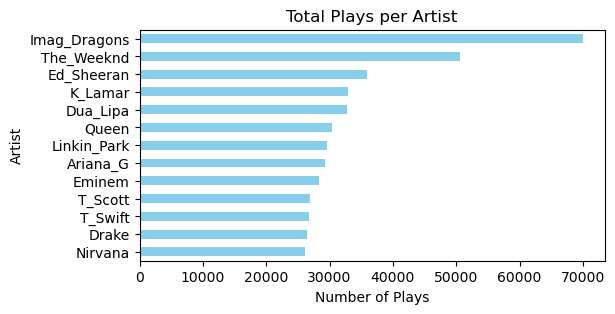

In [55]:
#bar plot for total plays for artist 
plt.figure(figsize=(6,3))
artistsTotal.plot(kind='barh',color='skyblue')
plt.title('Total Plays per Artist')
plt.xlabel('Number of Plays')
plt.ylabel('Artist')
plt.gca().invert_yaxis() # Highest plays on top
plt.show()

#### imagine dragons is most played artist

In [56]:
#finding correlation between 2 artists
corr=df.drop('User_ID',axis=1).corr()
print(corr)

               T_Swift     Drake     Queen  The_Weeknd    Eminem   Nirvana  \
T_Swift       1.000000 -0.034909  0.016708    0.430967  0.103697  0.005268   
Drake        -0.034909  1.000000  0.034851    0.318558  0.479559  0.056764   
Queen         0.016708  0.034851  1.000000   -0.034862 -0.050796  0.624603   
The_Weeknd    0.430967  0.318558 -0.034862    1.000000  0.533649  0.003105   
Eminem        0.103697  0.479559 -0.050796    0.533649  1.000000  0.033161   
Nirvana       0.005268  0.056764  0.624603    0.003105  0.033161  1.000000   
Ed_Sheeran    0.549654 -0.044716  0.017243    0.512031  0.018056 -0.019142   
T_Scott       0.022842  0.429038 -0.031300    0.445777  0.594250  0.059821   
Linkin_Park   0.048254  0.040036  0.629270    0.011910 -0.032408  0.662445   
Dua_Lipa      0.500530 -0.038885 -0.043878    0.467487  0.044212 -0.070524   
K_Lamar       0.042485  0.494921 -0.038045    0.494242  0.687372  0.026662   
Imag_Dragons  0.418376  0.009569  0.411859    0.343584  0.016059

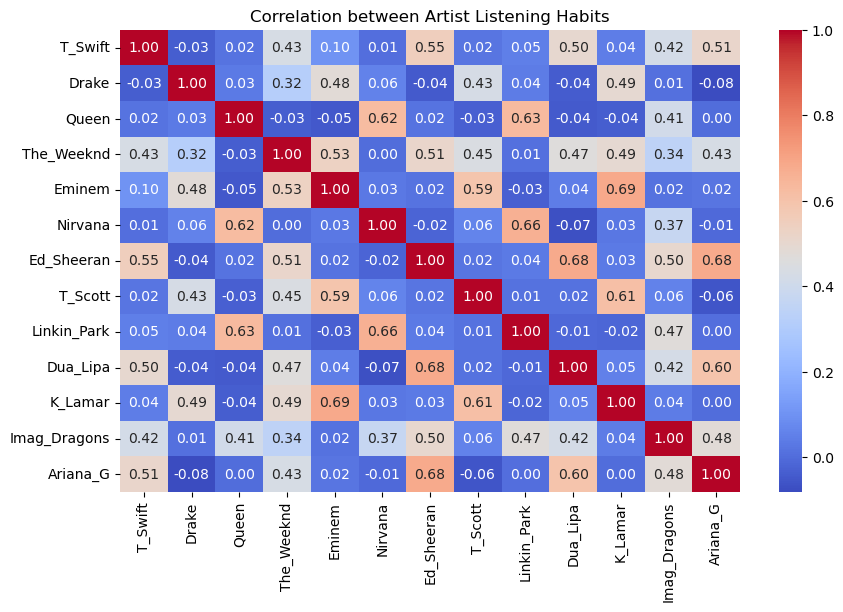

In [57]:
#showing the correlation visually on heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation between Artist Listening Habits')
plt.show()
#if the correlation between 2 artists is nearer to 1.0 it means that people who listen to artist A also have chance that they listen to artist B

#### people who listen to K Lamar most probably also listen to Eminem

In [58]:
#to show which user has played for longer period including all artists
df['Total_plays']=df.drop('User_ID',axis=1).sum(axis=1)

In [82]:
Top5=df[['User_ID','Total_plays']].sort_values(by='Total_plays',ascending=False).head()
print(Top5)

       User_ID  Total_plays
341  User_1342       2343.0
124  User_1125       2266.0
140  User_1141       2119.0
388  User_1389       2103.0
129  User_1130       2030.0


#### user1342 has most total plays

In [66]:
#diving the artists into three major genres
genre_map = {
    'T_Swift': 'Pop', 'Ed_Sheeran': 'Pop', 'Dua_Lipa': 'Pop', 'Ariana_G': 'Pop', 'The_Weeknd': 'Pop',
    'Drake': 'Rap', 'Eminem': 'Rap', 'T_Scott': 'Rap', 'K_Lamar': 'Rap',
    'Queen': 'Rock', 'Nirvana': 'Rock', 'Linkin_Park': 'Rock', 'Imag_Dragons': 'Rock'
}

C:\Users\manas\AppData\Local\Temp\ipykernel_16204\3882451339.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  genre_totals=df.drop(columns=['User_ID','Total_plays']).rename(columns=genre_map).groupby(level=0,axis=1).sum().sum()


<Axes: title={'center': 'Market Share by Genre'}>

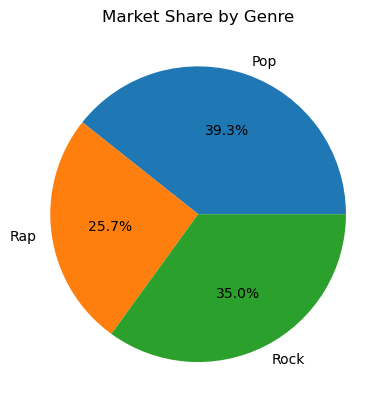

In [65]:
genre_totals=df.drop(columns=['User_ID','Total_plays']).rename(columns=genre_map).groupby(level=0,axis=1).sum().sum()
genre_totals.plot(kind='pie',autopct='%1.1f%%',title='Market Share by Genre') 

In [67]:
#to see how many  users are obsessed fans
artist_cols=df.columns.drop(['User_ID','Total_plays'])
shares=df[artist_cols].div(df['Total_plays'],axis=0)
#print(shares)

In [21]:
loyal_users = shares[shares.max(axis=1) > 0.7]
print(f"Number of 'Obsessed' fans: {len(loyal_users)}")

Number of 'Obsessed' fans: 1


In [22]:
def suggest_artists(artist_name):
    if artist_name not in artists:
        return "Artist not found. Check spelling (e.g., 'T_Swift', 'Drake')"
    recommendations = corr[artist_name].sort_values(ascending=False).drop(artist_name)
    print(f"Because you listen to {artist_name}, you might also like:")
    return recommendations.head(3)

In [23]:
print(suggest_artists('Drake'))

Because you listen to Drake, you might also like:
K_Lamar    0.494921
Eminem     0.479559
T_Scott    0.429038
Name: Drake, dtype: float64


In [24]:
print(suggest_artists('Dua_Lipa'))

Because you listen to Dua_Lipa, you might also like:
Ed_Sheeran    0.680850
Ariana_G      0.596334
T_Swift       0.500530
Name: Dua_Lipa, dtype: float64


### **The Giant:** 
#### Imagine Dragons is the undisputed king of this dataset (highest total plays and highest fan favorite count).
### **Genre Dominance:**
#### Pop is the most consumed genre, but Rock fans show very high engagement.
### **The Crossover:** 
#### There is a very high correlation between K_Lamar and Eminem ($0.69$), suggesting a massive overlap in their fanbases.

In [27]:
#"who is the most adventurous?"
#A Diversity Score counts how many different artists a user listens to.
artist_cols = ['T_Swift', 'Drake', 'Queen', 'The_Weeknd', 'Eminem', 'Nirvana', 
               'Ed_Sheeran', 'T_Scott', 'Linkin_Park', 'Dua_Lipa', 
               'K_Lamar', 'Imag_Dragons', 'Ariana_G']
df['Total_Plays'] = df[artist_cols].sum(axis=1)
df['Diversity_Score'] = (df[artist_cols] > 0).sum(axis=1)
print(df[['User_ID', 'Diversity_Score', 'Total_Plays']].sort_values(by='Diversity_Score', ascending=False).head())

       User_ID  Diversity_Score  Total_Plays
141  User_1142               13       1711.0
387  User_1388               13       1463.0
389  User_1390               13       1330.0
333  User_1334               13       1694.0
83   User_1084               13       1092.0


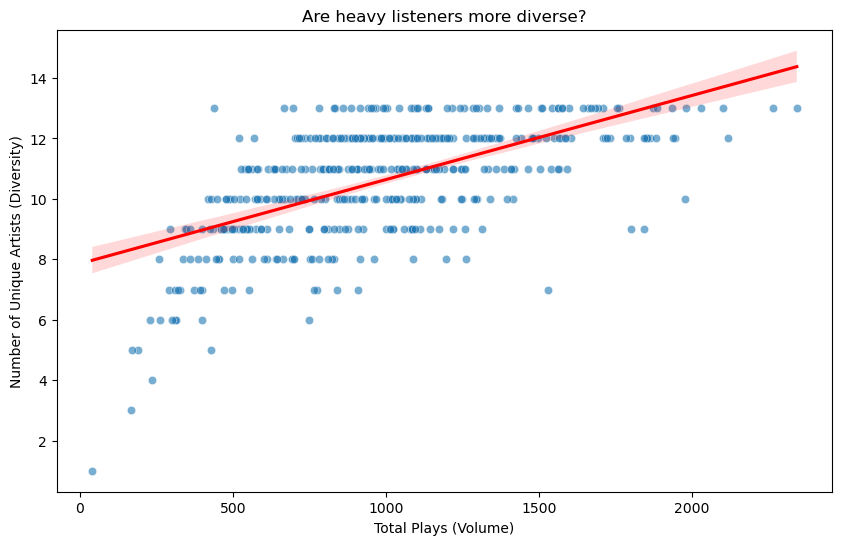

In [28]:
#see if "High Volume" listeners are also "High Diversity" listeners
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='Total_Plays',y='Diversity_Score',alpha=0.6)
#adding trend line
sns.regplot(data=df,x='Total_Plays',y='Diversity_Score',scatter=False,color='red')
plt.title('Are heavy listeners more diverse?')
plt.xlabel('Total Plays (Volume)')
plt.ylabel('Number of Unique Artists (Diversity)')
plt.show()

### **When you look at this scatter plot, look for these types of people:**

#### **The Loyalists (Bottom-Right):** High plays but low diversity. These fans listen to one or two artists on repeat but don't "binge" listen.

#### **The Casuals (Bottom-Left):** Low plays and low diversity. They probably only listen to music occasionally.

#### **The Explorers (Top-Right):** High plays and high diversity. These are your most valuable users because they consume everything and are likely to discover new music you suggest.

#### **The Samplers (Top-Left):** Low plays and high diversiry. These people have listened to almost every artist but less no of times

In [29]:
print(f"Average number of artists per user: {df['Diversity_Score'].mean():.2f}")
print(f"Most artists listened to by one person: {df['Diversity_Score'].max()}")
print(f"Least artists listened to by one person: {df['Diversity_Score'].min()}")

Average number of artists per user: 10.60
Most artists listened to by one person: 13
Least artists listened to by one person: 1


In [34]:
user_genre_stats = df[artist_cols].rename(columns=genre_map).groupby(level=0, axis=1).sum()
#print(user_genre_stats)

C:\Users\manas\AppData\Local\Temp\ipykernel_16204\1750980634.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  user_genre_stats = df[artist_cols].rename(columns=genre_map).groupby(level=0, axis=1).sum()


In [35]:
df['User_Persona'] = user_genre_stats.idxmax(axis=1)
print("--- User Persona Counts ---")
print(df['User_Persona'].value_counts())

--- User Persona Counts ---
User_Persona
Pop     190
Rock    163
Rap     100
Name: count, dtype: int64


C:\Users\manas\AppData\Local\Temp\ipykernel_16204\2044729384.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='User_Persona', data=df, palette='viridis')


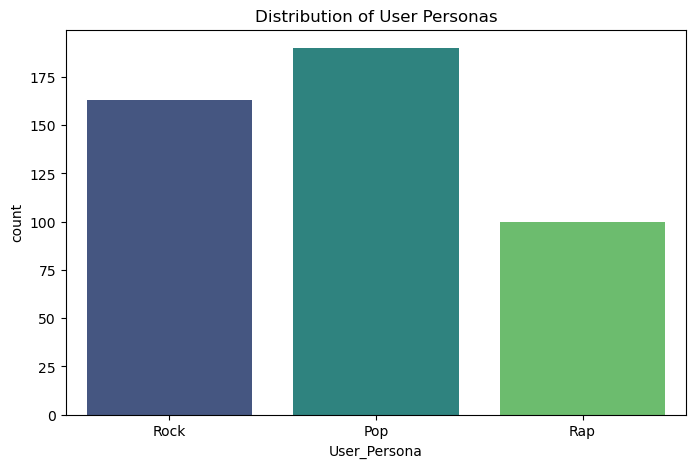

In [36]:
plt.figure(figsize=(8,5))
sns.countplot(x='User_Persona', data=df, palette='viridis')
plt.title('Distribution of User Personas')
plt.show()

#### the highest no of persons listen to pop music (190)

In [74]:
#to find the artist who acts as a bridge between different musical worlds.
gatekeeper_scores = {}

for artist in artist_cols:
    my_genre = genre_map[artist]
    # Find artists that are NOT in my genre
    other_genre_artists = [a for a in artist_cols if genre_map[a] != my_genre]
    # Average correlation with those "outsiders"
    gatekeeper_scores[artist] = corr[artist][other_genre_artists].mean()

In [75]:
gatekeeper_df = pd.Series(gatekeeper_scores).sort_values(ascending=False)
print("--- Gatekeeper Scores (Higher = Better Bridge) ---")
print(gatekeeper_df)

--- Gatekeeper Scores (Higher = Better Bridge) ---
The_Weeknd      0.264495
Imag_Dragons    0.254397
T_Swift         0.077840
Eminem          0.076541
K_Lamar         0.071151
Ed_Sheeran      0.070750
T_Scott         0.060842
Dua_Lipa        0.046134
Ariana_G        0.045255
Drake           0.028961
Linkin_Park     0.010210
Nirvana         0.009642
Queen          -0.014259
dtype: float64


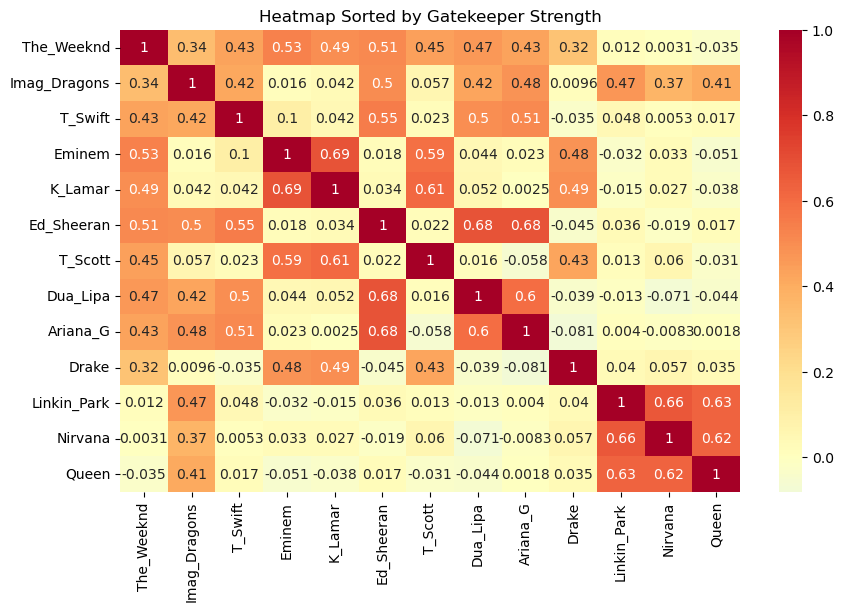

In [78]:
sorted_artists = gatekeeper_df.index
sorted_corr = corr.loc[sorted_artists, sorted_artists]

plt.figure(figsize=(10,6))
sns.heatmap(sorted_corr, annot=True, cmap='RdYlBu_r', center=0)
plt.title('Heatmap Sorted by Gatekeeper Strength')
plt.show()

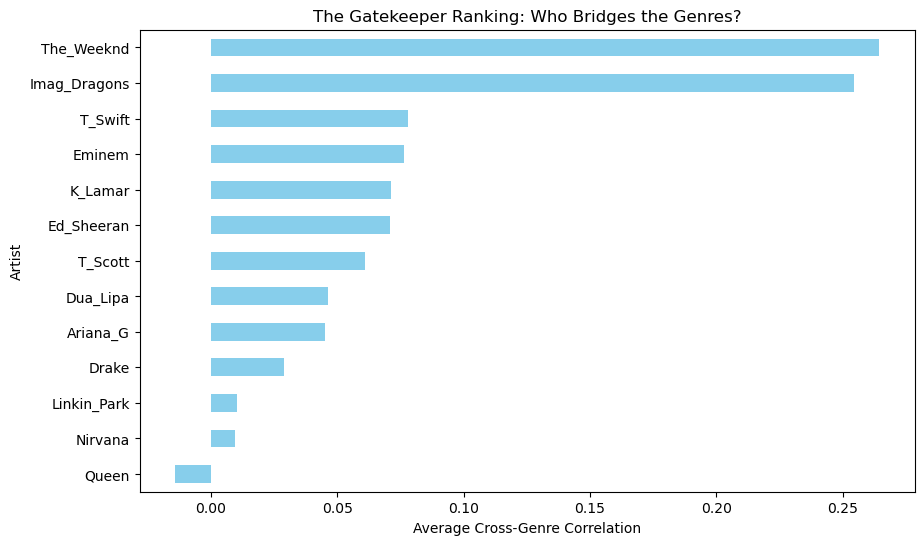

In [79]:
plt.figure(figsize=(10, 6))
gatekeeper_df.plot(kind='barh', color='skyblue')
plt.title('The Gatekeeper Ranking: Who Bridges the Genres?')
plt.xlabel('Average Cross-Genre Correlation')
plt.ylabel('Artist')
plt.gca().invert_yaxis() # Put the #1 at the top
plt.show()

#### The_Weeknd serves as the strongest connection between different fanbases, making them the most effective for broad platform promotion.